# 07 · Representation-space comparison

Compare multiple numerical representations of the same observations using CKA, CCA, distance-space similarity, Mantel and Procrustes. This notebook is a direct blueprint for representation-comparison views in the future local application.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_representation_similarity, analyze_pca
from scipy.spatial.distance import pdist
from scipy.spatial import procrustes
frame,dataset=load_tabular_demo(); A=load_feature_demo('representation_a'); B=load_feature_demo('representation_b'); C=load_feature_demo('representation_c')
AB=analyze_representation_similarity(A,B,cca_components=4,mantel_permutations=19,random_state=42)
AC=analyze_representation_similarity(A,C,cca_components=4,mantel_permutations=19,random_state=42)
BC=analyze_representation_similarity(B,C,cca_components=4,mantel_permutations=19,random_state=42)

## Pairwise representation similarity matrix (CKA)

findfont: Failed to find font weight semibold, now using 700.


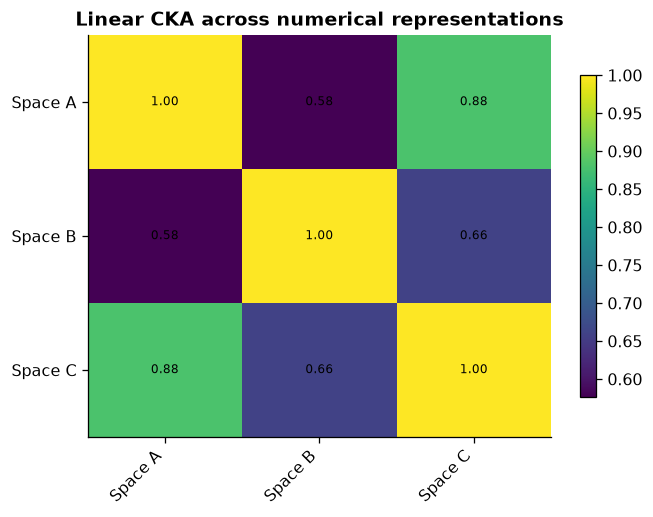

,Space A,Space B,Space C
Space A,1.000000,0.576693,0.880305
Space B,0.576693,1.000000,0.659732
Space C,0.880305,0.659732,1.000000


In [2]:
labels=['Space A','Space B','Space C']; cka=pd.DataFrame(np.eye(3),index=labels,columns=labels); vals={(0,1):AB.cka.iloc[0].cka,(0,2):AC.cka.iloc[0].cka,(1,2):BC.cka.iloc[0].cka}
for (i,j),v in vals.items(): cka.iat[i,j]=cka.iat[j,i]=v
matrix_heatmap(cka,title='Linear CKA across numerical representations'); plt.show(); display(cka)

## Canonical correlation spectrum

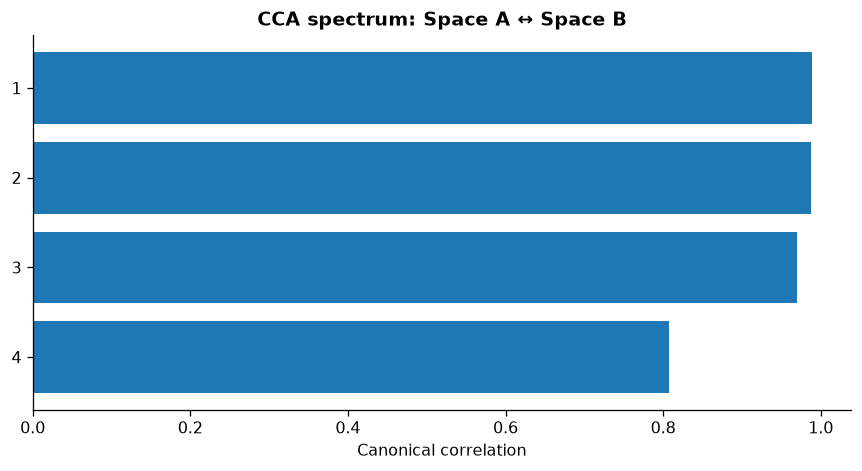

In [3]:
corr=AB.cca.correlations.query('status=="ok"'); bar_metric(corr,label='component',value='canonical_correlation',title='CCA spectrum: Space A ↔ Space B',ylabel='Canonical correlation'); plt.show()

## Canonical scores coloured by group

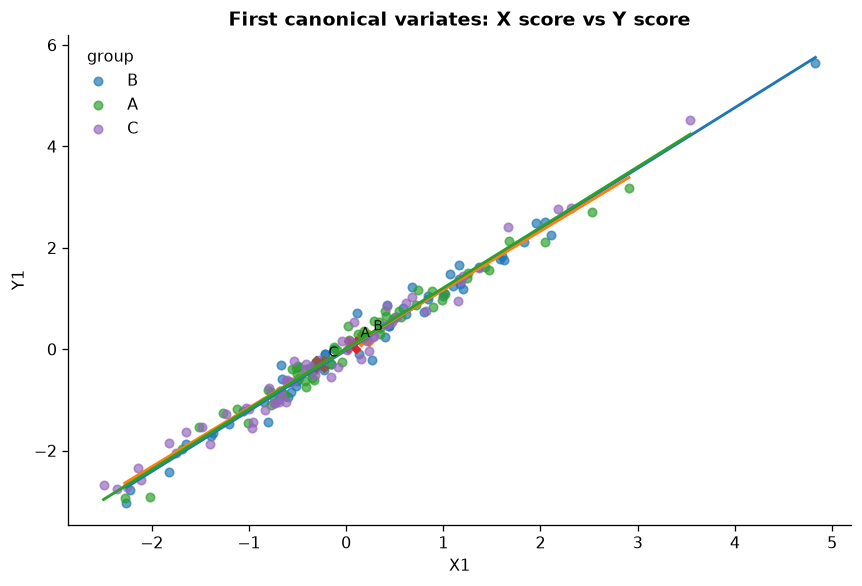

In [4]:
xs=AB.cca.x_scores.rename(columns={'CC1':'X1','CC2':'X2'}); ys=AB.cca.y_scores.rename(columns={'CC1':'Y1','CC2':'Y2'}); joint=xs[['observation_id','X1']].merge(ys[['observation_id','Y1']],on='observation_id').merge(frame[['id','group']],left_on='observation_id',right_on='id'); scatter_by_group(joint,x='X1',y='Y1',group='group',title='First canonical variates: X score vs Y score'); plt.show()

## Distance-space comparison

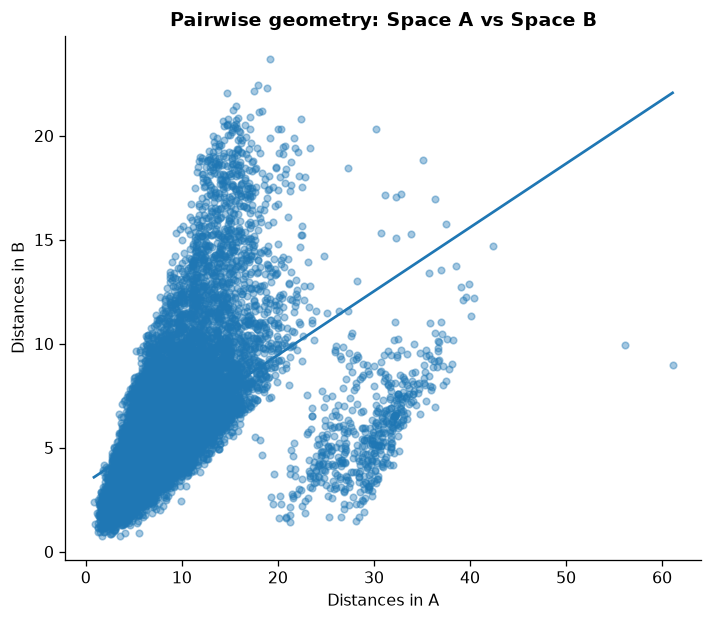

,metric,method,coefficient,p_value,n_pairs,status,reason
0,euclidean,spearman,0.72625,0.0,16110,ok,None


,metric,correlation,p_value,permutations,alternative,status,reason
0,euclidean,0.517304,0.05,19,two-sided,ok,None


In [5]:
xa=A.to_array(); xb=B.to_array(); da=pdist(xa); db=pdist(xb); distance_scatter(da,db,title='Pairwise geometry: Space A vs Space B',xlabel='Distances in A',ylabel='Distances in B'); plt.show(); display(AB.distance_similarity); display(AB.mantel)

## Procrustes for same-dimensional related spaces

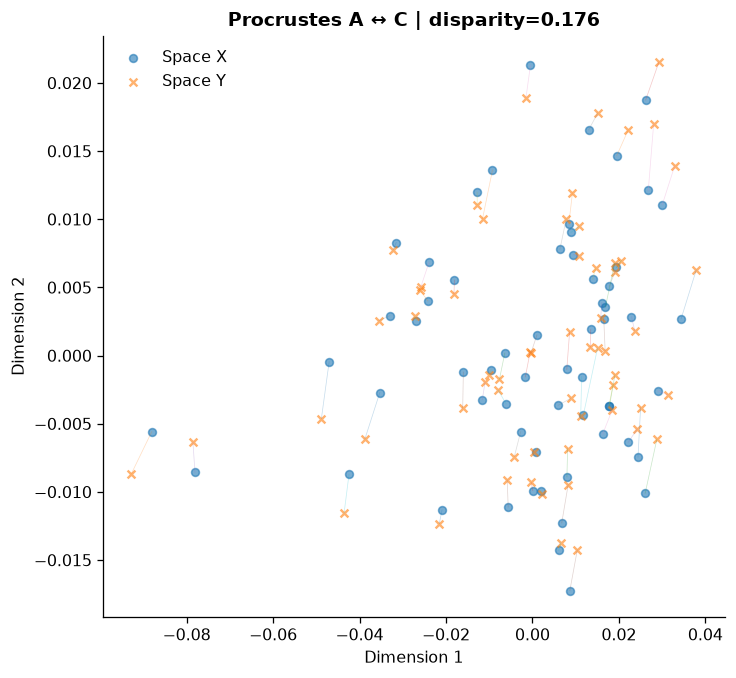

,disparity,similarity,n_dimensions,status,reason
0,0.175695,0.824305,12,ok,None


In [6]:
a=A.to_array(); c=C.to_array(); m1,m2,disp=procrustes(a,c); procrustes_segments(m1[:60,:2],m2[:60,:2],title=f'Procrustes A ↔ C | disparity={disp:.3f}'); plt.show(); display(AC.procrustes)

## Compare all metrics across representation pairs

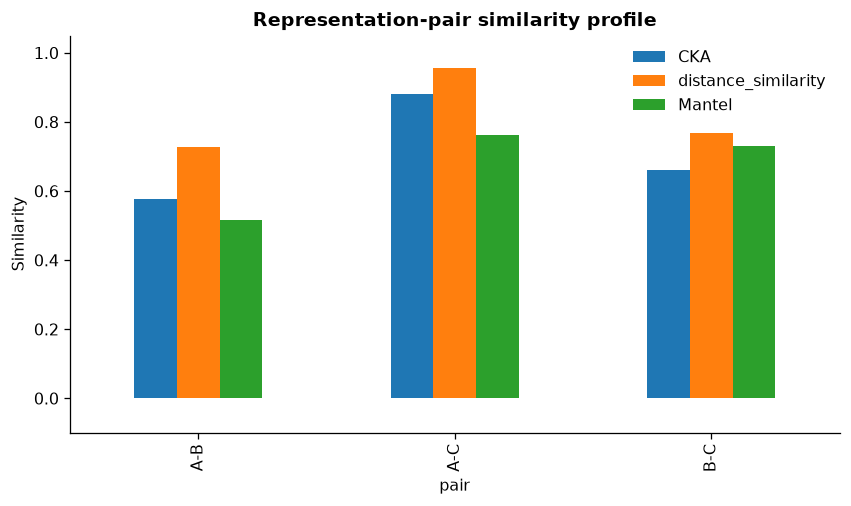

,CKA,distance_similarity,Mantel
pair,,,
A-B,0.576693,0.726250,0.517304
A-C,0.880305,0.957450,0.762137
B-C,0.659732,0.767973,0.730210


In [7]:
summary=pd.DataFrame([
 {'pair':'A-B','CKA':AB.cka.iloc[0].cka,'distance_similarity':AB.distance_similarity.iloc[0].coefficient,'Mantel':AB.mantel.iloc[0].correlation},
 {'pair':'A-C','CKA':AC.cka.iloc[0].cka,'distance_similarity':AC.distance_similarity.iloc[0].coefficient,'Mantel':AC.mantel.iloc[0].correlation},
 {'pair':'B-C','CKA':BC.cka.iloc[0].cka,'distance_similarity':BC.distance_similarity.iloc[0].coefficient,'Mantel':BC.mantel.iloc[0].correlation},
]).set_index('pair'); fig,ax=plt.subplots(figsize=(7.5,4.5)); summary.plot(kind='bar',ax=ax); ax.set_ylim(-.1,1.05); ax.set_ylabel('Similarity'); ax.set_title('Representation-pair similarity profile'); finish(fig); plt.show(); display(summary)

## Interactive canonical-score explorer

In [8]:
import plotly.express as px
fig=px.scatter(joint,x='X1',y='Y1',color='group',hover_name='observation_id',title='Interactive CCA score alignment')
fig